In [1]:
import pandas as pd


df = pd.read_csv('final_df.csv')

df['study_group'] = df['study_group'].replace({
    'pre_diabetes_lifestyle_controlled': 'pre-diabetic'
})

df.head()

,participant_id,study_group,age,race_American Indian or Alaska Native,race_Asian,race_Black or African American,race_Middle Eastern,race_Native Hawaiian or other Pacific Islander,race_Not specified,"race_Other race, ethnicity or origin",...,max_glucose,min_glucose,std_glucose,tir,tar,tbr,cv_glucose,split,race,sex
0,1001,pre-diabetic,69,0,0,0,0,0,0,0,...,203.0,76.0,18.486719,98.879552,1.120448,0.000000,14.992466,train,White or Caucasian,Female
1,1002,healthy,69,0,0,1,0,0,0,0,...,185.0,40.0,21.705531,96.955198,0.086994,2.957808,17.029436,train,Black or African American,Male
2,1003,oral_medication_and_or_non_insulin_injectable_...,82,0,0,0,0,0,0,1,...,400.0,116.0,44.004119,27.643133,72.356867,0.000000,21.145328,test,"Other race, ethnicity or origin",Male
3,1004,oral_medication_and_or_non_insulin_injectable_...,61,0,1,0,0,0,0,0,...,309.0,77.0,34.992677,46.603641,53.396359,0.000000,18.547665,train,Asian,Male
4,1005,insulin_dependent,58,0,0,1,0,0,0,0,...,400.0,121.0,60.464226,7.787934,92.212066,0.000000,22.768719,train,Black or African American,Male


In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

def clean_col(c):
    return re.sub(r'[\[\]<>]', '', c)

race_cols = [c for c in df.columns if c.startswith('race_')]
df['race'] = df[race_cols].idxmax(axis=1).str.replace('race_', '', regex=False)

sex_cols = [c for c in df.columns if c.startswith('sex_')]
df['sex'] = df[sex_cols].idxmax(axis=1).str.replace('sex_', '', regex=False)

target_col = 'import_insulin, Insulin [Units/volume] in Serum o'

exclude = {
    'participant_id', 'study_group', 'split',
    target_col,
    'import_glucose, Glucose [Mass/volume] in Serum or',
    'max_glucose',
    'min_glucose',
    'mean_glucose',
    'std_glucose',
    'tir',
    'tar',
    'cv_glucose'
}
feature_cols = [
    c for c in df.columns
    if c not in exclude
    and not c.startswith('race_')
    and not c.startswith('sex_')
]

print('Features:', feature_cols)

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
}

divider = '=' * 50
results = {}
prediction_rows = []
enet_coefs = {}

for group in df['study_group'].dropna().unique():
    print('')
    print(divider)
    print('Study Group:', group)
    print(divider)

    group_df = df[df['study_group'] == group].copy()
    group_df = group_df.replace([np.inf, -np.inf], np.nan)
    group_df = group_df.dropna(subset=feature_cols + [target_col])

    if len(group_df) < 20:
        print('Skipping - only', len(group_df), 'rows after dropping NAs (too few to model)')
        continue

    X = pd.get_dummies(group_df[feature_cols], columns=['sex', 'race'], drop_first=True)
    y = group_df[target_col]

    X_train = X[group_df['split'] == 'train']
    X_test  = X[group_df['split'] == 'test']
    y_train = y[group_df['split'] == 'train']
    y_test  = y[group_df['split'] == 'test']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ----- Linear Regression -----
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    lr_preds = lr.predict(X_test_scaled)

    lr_r2 = r2_score(y_test, lr_preds)
    lr_mse = mean_squared_error(y_test, lr_preds)

    print('')
    print('Linear Regression')
    print('  R-squared:', lr_r2)
    print('  MSE:', lr_mse)

    # ----- ElasticNet -----
    enet = ElasticNetCV(cv=5, random_state=42, max_iter=10000)
    enet.fit(X_train_scaled, y_train)
    enet_preds = enet.predict(X_test_scaled)

    enet_r2 = r2_score(y_test, enet_preds)
    enet_mse = mean_squared_error(y_test, enet_preds)

    print('')
    print('ElasticNet (alpha=', enet.alpha_, ', l1_ratio=', enet.l1_ratio_, ')')
    print('  R-squared:', enet_r2)
    print('  MSE:', enet_mse)

    selected_features = X.columns[enet.coef_ != 0].tolist()
    print('  Selected features (non-zero coef):', selected_features)
    enet_coefs[group] = pd.Series(enet.coef_, index=X.columns)
    print('  ElasticNet weights:')
    print(enet_coefs[group].sort_values())


    # ----- XGBoost with GridSearchCV -----
    X_train_xgb = X_train.copy()
    X_test_xgb = X_test.copy()
    X_train_xgb.columns = [clean_col(c) for c in X_train_xgb.columns]
    X_test_xgb.columns = [clean_col(c) for c in X_test_xgb.columns]

    xgb_grid = GridSearchCV(
        estimator=XGBRegressor(random_state=42, n_jobs = 1),
        param_grid=xgb_param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )
    xgb_grid.fit(X_train_xgb, y_train)
    xgb_preds = xgb_grid.predict(X_test_xgb)

    test_ids = group_df.loc[group_df['split'] == 'test', 'participant_id'].values
    prediction_rows.append(pd.DataFrame({
        'participant_id': test_ids,
        'study_group': group,
        'actual_insulin': y_test.values,
        'pred_insulin_lr': lr_preds,
        'pred_insulin_enet': enet_preds,
        'pred_insulin_xgb': xgb_preds,
    }))

    xgb_r2 = r2_score(y_test, xgb_preds)
    xgb_mse = mean_squared_error(y_test, xgb_preds)

    print('')
    print('XGBoost (GridSearchCV)')
    print('  Best params:', xgb_grid.best_params_)
    print('  R-squared:', xgb_r2)
    print('  MSE:', xgb_mse)

    results[group] = {
        'n': len(group_df),
        'linear_r2': lr_r2,
        'linear_mse': lr_mse,
        'elasticnet_r2': enet_r2,
        'elasticnet_mse': enet_mse,
        'xgboost_r2': xgb_r2,
        'xgboost_mse': xgb_mse,
        'xgboost_best_params': xgb_grid.best_params_
    }

print('')
print(divider)
print('Summary')
print(divider)
summary_df_2 = pd.DataFrame(results).T
print(summary_df_2)

prediction_2 = pd.concat(prediction_rows, ignore_index=True)
print('')
print('Prediction dataframe:')
print(prediction_2.head())

Features: ['age', 'pulse_vsorres, Heart Rate (bpm)', 'bmi_vsorres, BMI', 'import_hba1c, Hemoglobin A1c/Hemoglobin.total in ', 'import_albumin, Albumin [Mass/volume] in Serum or', 'import_a_g_ratio, Albumin/Globulin ratio', 'import_globulin_total, Globulin [Mass/volume] in ', 'import_protein_total, Protein [Mass/volume] in Se', 'import_c_peptide, C peptide [Mass/volume] in Seru', 'import_calcium, Calcium [Mass/volume] in Serum or', 'import_chloride, Chloride [Moles/volume] in Serum', 'import_sodium, Sodium [Moles/volume] in Serum or ', 'import_potassium, Potassium [Moles/volume] in Ser', 'import_carbon_dioxide_total, Carbon dioxide, tota', 'import_creatinine, Creatinine [Mass/volume] in Se', 'import_bun, Urea nitrogen [Mass/volume] in Serum ', 'import_buncreatinineratio, BUN/Creatinine ratio', 'import_urine_albumin, Albumin [Mass/volume] in Ur', 'import_urine_creatinine, Creatinine [Mass/volume]', 'import_alkaline_phosphatase, Alkaline phosphatase', 'import_alt_got, Alanine aminotransfe

In [3]:
summary_df_2

,n,linear_r2,linear_mse,elasticnet_r2,elasticnet_mse,xgboost_r2,xgboost_mse,xgboost_best_params
pre-diabetic,549,0.698229,0.24609,0.723951,0.225114,0.648712,0.286471,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
healthy,759,0.736007,0.501361,0.732873,0.507313,0.711044,0.54877,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
oral_medication_and_or_non_insulin_injectable_medication_controlled,663,0.702614,0.430714,0.714849,0.412993,0.798821,0.291375,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
insulin_dependent,246,0.072363,1.43954,0.078877,1.429431,0.156841,1.308445,"{'colsample_bytree': 0.7, 'learning_rate': 0.0..."


In [ ]:
enet_coef_df = pd.DataFrame(enet_coefs)
enet_coef_df


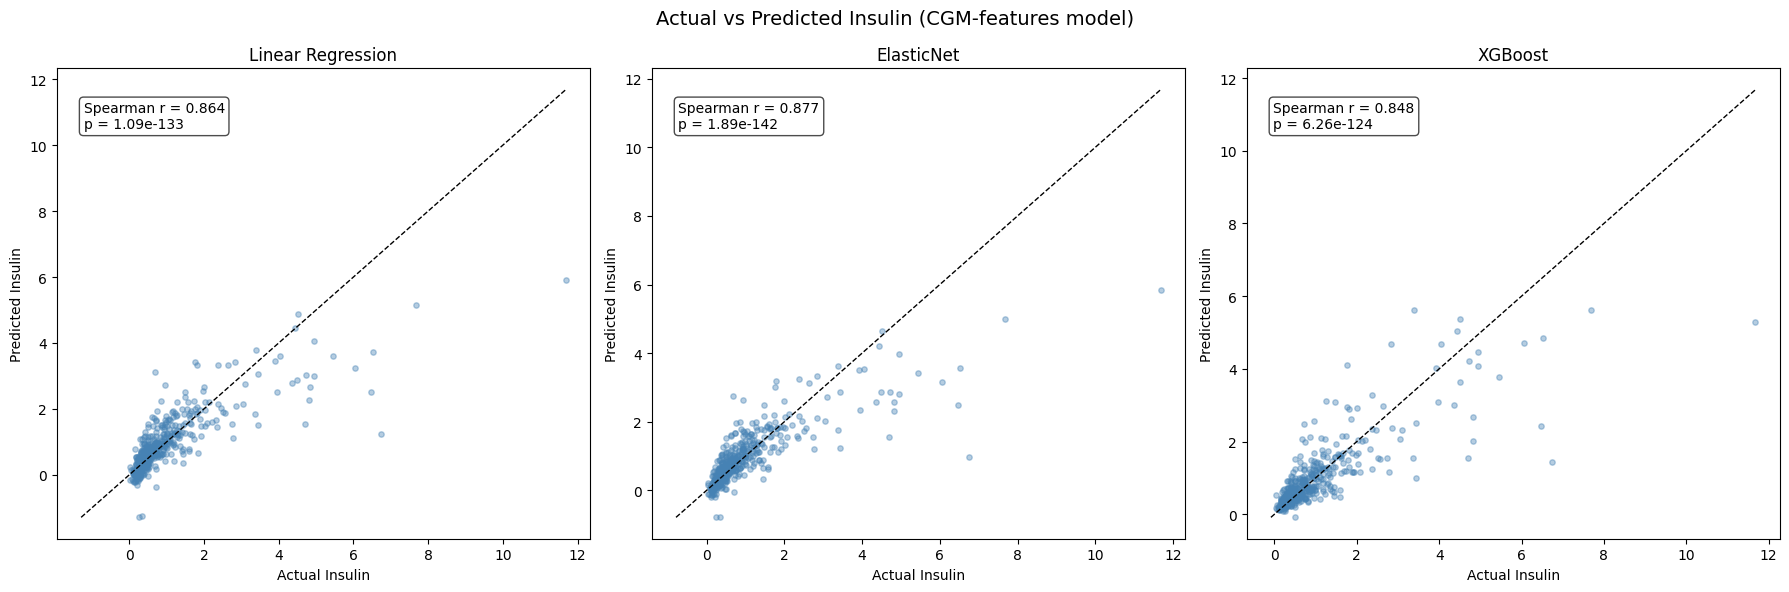

In [4]:
import matplotlib.pyplot as plt
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = ['lr', 'enet', 'xgb']
names = ['Linear Regression', 'ElasticNet', 'XGBoost']

for ax, model, name in zip(axes, models, names):
    actual = prediction_2['actual_insulin']
    preds = prediction_2[f'pred_insulin_{model}']
    r, p = stats.spearmanr(actual, preds)

    ax.scatter(actual, preds, alpha=0.4, s=15, color='steelblue')
    lims = [min(actual.min(), preds.min()), max(actual.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)

    p_str = f'{p:.2e}' if p < 0.001 else f'{p:.3f}'
    ax.text(0.05, 0.93, f'Spearman r = {r:.3f}\np = {p_str}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    ax.set_xlabel('Actual Insulin')
    ax.set_ylabel('Predicted Insulin')
    ax.set_title(name)

fig.suptitle('Actual vs Predicted Insulin (CGM-features model)', fontsize=14)
plt.tight_layout()